In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
customer = pd.read_csv(r"C:\\Users\\ANSHUMAN RAI\\OneDrive\\Desktop\\Customer Model\\Data\\customer_dataset.csv")
purchase = pd.read_csv(r"C:\\Users\\ANSHUMAN RAI\\OneDrive\\Desktop\\Customer Model\\Data\\sales_dataset.csv")

In [29]:
customer_spending = purchase.groupby("customer_id")["revenue"].sum().reset_index()
customer_spending.rename(columns={"revenue":"total_spent"}, inplace=True)
customer = customer.merge(customer_spending, on="customer_id", how="left")
customer["total_spent"] = customer["total_spent"].fillna(0)
purchase_count = purchase.groupby("customer_id").size().reset_index(name="number_of_purchases")

customer = customer.merge(purchase_count, on="customer_id", how="left")

customer["number_of_purchases"] = customer["number_of_purchases"].fillna(0).astype(int)

In [30]:
membership_weight = {
    "Silver":1.0,
    "Gold":1.3,
    "Platinum":1.7
}
customer["lifetime_value"] = (
    customer["total_spent"] *
    customer["membership_level"].map(membership_weight)
)

In [31]:
customer.head()

,customer_id,age,gender,city,membership_level,join_date,lifetime_value,total_spent,number_of_purchases
0,5000,23,Male,Bangalore,Platinum,08-07-2022,2660.5,1565.0,5
1,5001,22,Male,Delhi,Silver,28-08-2022,670.0,670.0,4
2,5002,62,Female,Bangalore,Platinum,17-09-2021,1275.0,750.0,2
3,5003,46,Female,Delhi,Silver,08-10-2021,1370.0,1370.0,4
4,5004,29,Male,Delhi,Silver,22-12-2021,1235.0,1235.0,5


In [32]:
customer["join_date"] = pd.to_datetime(customer["join_date"], dayfirst=True)
customer["membership_years"] = 2024 - customer["join_date"].dt.year

In [33]:
customer.head()

,customer_id,age,gender,city,membership_level,join_date,lifetime_value,total_spent,number_of_purchases,membership_years
0,5000,23,Male,Bangalore,Platinum,2022-07-08,2660.5,1565.0,5,2
1,5001,22,Male,Delhi,Silver,2022-08-28,670.0,670.0,4,2
2,5002,62,Female,Bangalore,Platinum,2021-09-17,1275.0,750.0,2,3
3,5003,46,Female,Delhi,Silver,2021-10-08,1370.0,1370.0,4,3
4,5004,29,Male,Delhi,Silver,2021-12-22,1235.0,1235.0,5,3


In [34]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_city = LabelEncoder()
le_membership = LabelEncoder()

customer["gender"] = le_gender.fit_transform(customer["gender"])
customer["city"] = le_city.fit_transform(customer["city"])
customer["membership_level"] = le_membership.fit_transform(customer["membership_level"])

In [35]:
customer.head()

,customer_id,age,gender,city,membership_level,join_date,lifetime_value,total_spent,number_of_purchases,membership_years
0,5000,23,1,0,1,2022-07-08,2660.5,1565.0,5,2
1,5001,22,1,2,2,2022-08-28,670.0,670.0,4,2
2,5002,62,0,0,1,2021-09-17,1275.0,750.0,2,3
3,5003,46,0,2,2,2021-10-08,1370.0,1370.0,4,3
4,5004,29,1,2,2,2021-12-22,1235.0,1235.0,5,3


In [72]:
features = [
    "age",
    "gender",
    "city",
    "total_spent",
    "membership_level",
    "membership_years",
    "number_of_purchases"
]

X = customer[features]
y = customer["lifetime_value"]

In [73]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  5000 non-null   int64  
 1   gender               5000 non-null   int64  
 2   city                 5000 non-null   int64  
 3   total_spent          5000 non-null   float64
 4   membership_level     5000 non-null   int64  
 5   membership_years     5000 non-null   int32  
 6   number_of_purchases  5000 non-null   int64  
dtypes: float64(1), int32(1), int64(5)
memory usage: 254.0 KB


In [74]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: lifetime_value
Non-Null Count  Dtype  
--------------  -----  
5000 non-null   float64
dtypes: float64(1)
memory usage: 39.2 KB


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
from sklearn.ensemble import RandomForestRegressor

model_customer = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_customer.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

pred = model_customer.predict(X_test)

rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 30.505198552106833
R2 Score: 0.9989067349049314


   Actual    Predicted
0  1339.0  1336.492886
1  1410.5  1407.903214
2  1261.0  1261.330175
3  1430.0  1429.872332
4  1475.0  1474.312271
5  1755.0  1750.909220
6  1795.0  1795.418214
7  1496.0  1496.623985
8   855.0   854.663750
9   980.0   979.975000


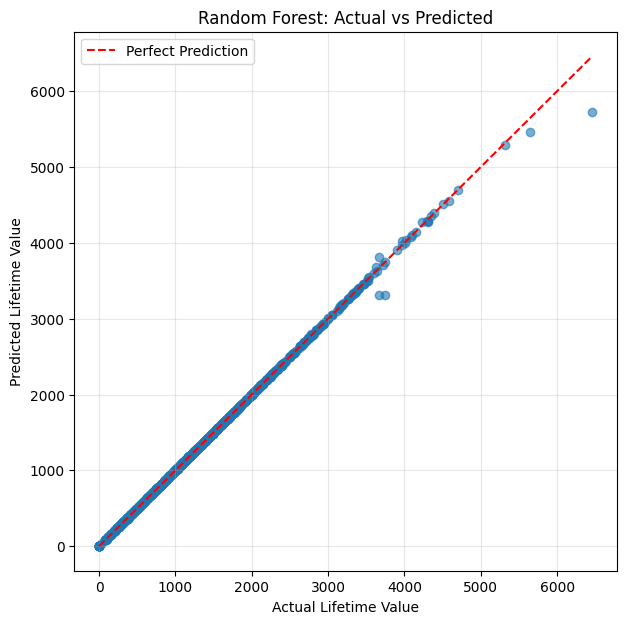

In [78]:
# Actual vs Predicted (Random Forest)
import matplotlib.pyplot as plt

actual_vs_pred = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
})

print(actual_vs_pred.head(10))

plt.figure(figsize=(7, 7))
plt.scatter(actual_vs_pred["Actual"], actual_vs_pred["Predicted"], alpha=0.6)
plt.plot(
    [actual_vs_pred["Actual"].min(), actual_vs_pred["Actual"].max()],
    [actual_vs_pred["Actual"].min(), actual_vs_pred["Actual"].max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
 )
plt.xlabel("Actual Lifetime Value")
plt.ylabel("Predicted Lifetime Value")
plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
from sklearn.ensemble import GradientBoostingRegressor,HistGradientBoostingRegressor,AdaBoostRegressor
import xgboost as xgb
boosting_model=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    subsample=1.0,
    loss='squared_error',
    random_state=42
)

In [63]:
boosting_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [64]:
GB_pred=boosting_model.predict(X_test)

In [65]:
print("r2 score")
r2_score(y_test,GB_pred)

r2 score


0.9983868505791531

In [66]:
print("MSE")
mean_squared_error(y_test,GB_pred)

MSE


1373.0831137204418

In [67]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
base_models = [
    ('rf',RandomForestRegressor(n_estimators=100,random_state=42)),
    ('dt',DecisionTreeRegressor(random_state=42)),
    ('lr',LinearRegression()),
    ('svr',SVR(kernel = 'rbf')),
    ('hgb',HistGradientBoostingRegressor(random_state=42))
]
meta_model = LinearRegression()
stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
    )

In [68]:
stacking_regressor.fit(X_train,y_train)

,estimators,"[('rf', ...), ('dt', ...), ...]"
,final_estimator,LinearRegression()
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [69]:
SR_pred=stacking_regressor.predict(X_test)

In [70]:
print("r2 score")
r2_score(y_test,SR_pred)

r2 score


0.9997122177313165

In [71]:
print("mse")
mean_squared_error(y_test,SR_pred)

mse


244.95497345187644